# Dependencias y constantes

In [1]:
# Import de librerías importantes
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd

# Librerías utilizadas en algunos análisis
from scipy.stats import linregress                  # Para el análisis de regresión lineal
from sklearn.linear_model import LinearRegression   # Para la regresión lineal múltiple
from sklearn import tree                            # Para la creación de árboles de decisión
from sklearn.ensemble import RandomForestRegressor  # Para la creación de bosques aleatorios (random forest)


# Para poder cargar los módulos escritos en la raíz del proyecto
from pathlib import Path
import sys

RAIZ_PROYECTO = Path().resolve().parent
sys.path.insert(0, str(RAIZ_PROYECTO))

from src.estadistica import *
from src.representacion import *
from src.utils import *

R_DATAFRAME = "../datos/out/df_procesado.csv"       # Ruta del dataframe en csv
DIR_SALIDA = "../salida"

SEMILLA = 1905                                      # Semilla para la generación de números aleatorios

In [2]:
# Funciones muy utilizadas en el cuaderno
def dataframe():
    """Función para cargar el dataframe desde el csv y convertir la columna Datetime a formato datetime."""
    df = pd.read_csv(R_DATAFRAME, parse_dates=['Datetime'])
    return df

# Cuaderno de estudio de variables

Este cuaderno Jupyter busca visualizar las variables a estudiar. De esta forma, podemos buscar relaciones entre estas (al menos, a primera vista) antes de comenzar a realizar pruebas más exhaustivas y exactas. El objetivo es discriminar métodos y relaciones a explorar en función del comportamiento aparente de estas variables.

## Lecturas de los piranómetros y células calibradas

Uno de los objetivos de este estudio es comprobar si es posible sustituir la instalación de piranómetros (que tienen un alto coste) utilizando otros sensores de irradiancia como células calibradas o simples placas monofaciales.

### Comprobación de la sustitubilidad directa de las mediciones

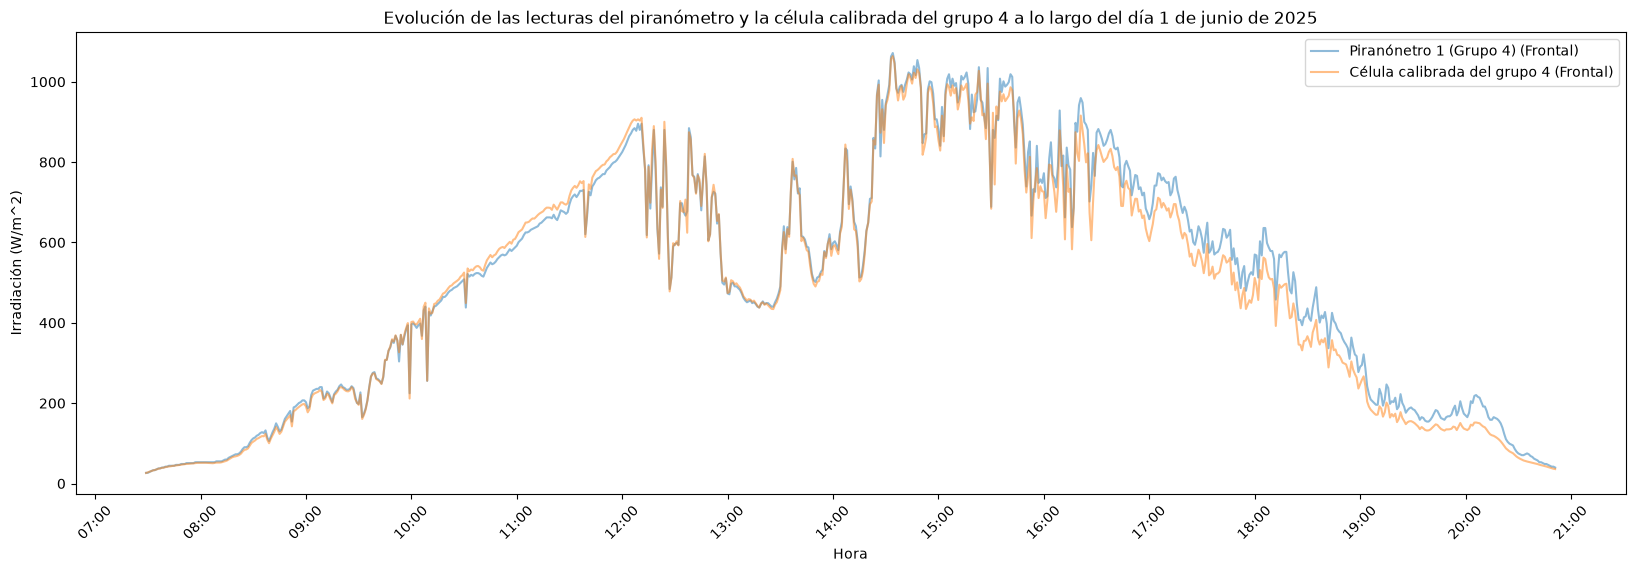

In [4]:
# Importo los datos desde el fichero CSV
df = dataframe()
df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df[(df['Datetime'].dt.day == 1) & (df['Datetime'].dt.month == 6) & (df['Datetime'].dt.year == 2025)]

# Hago un plot de las lecturas del piranómetro y la célula calibrada a lo largo de un día completo
df.index = df['Datetime']

fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(df.index, df['PIR F1'], label='Piranónetro 1 (Grupo 4) (Frontal)', alpha=0.5)
ax.plot(df.index, df['G FRONT'], label='Célula calibrada del grupo 4 (Frontal)', alpha=0.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:00'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

ax.set_xlabel('Hora')
ax.set_ylabel('Irradiación (W/m^2)')
ax.set_title('Evolución de las lecturas del piranómetro y la célula calibrada del grupo 4 a lo largo del día 1 de junio de 2025')
ax.legend()
plt.xticks(rotation=45)
plt.show()

Para comprobar si nuestras sospechas de que la célula calibrada hace la misma medición que el piranómetro, calculamos la significancia estadística de la diferencia entre las series utilizando la correlación de Pearson.

Resultados del análisis de regresión lineal entre las lecturas del piranómetro y la célula calibrada del grupo 4:
- Valor p de la regresión lineal: 0.00000
- La correlación es estadísticamente significativa.
- Coeficiente de correlación de Pearson: 0.99330


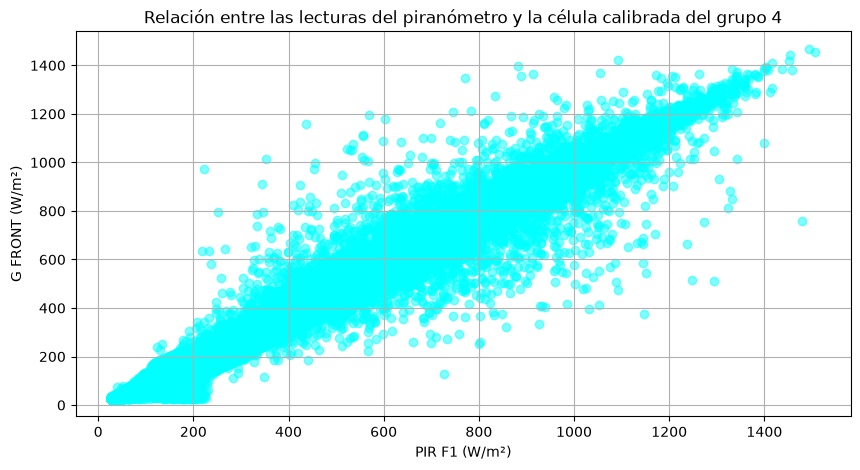

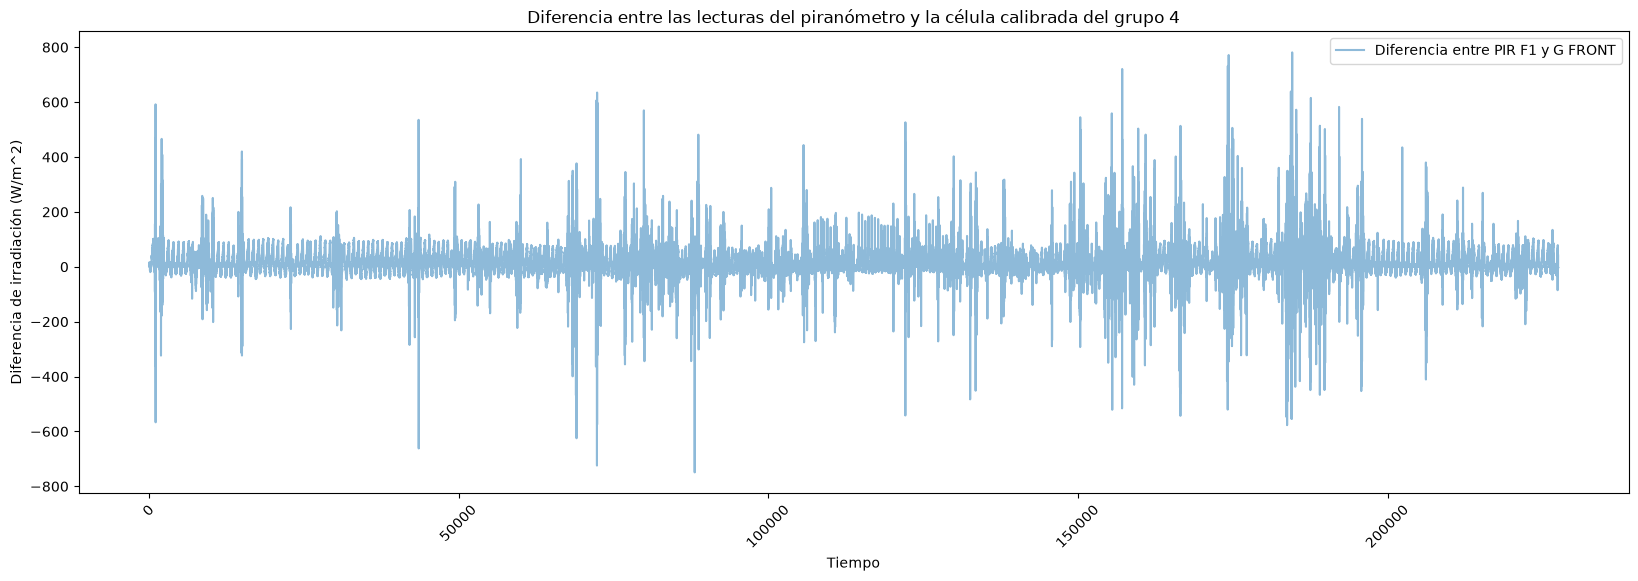

In [5]:
# Importo los datos desde el fichero CSV
df = dataframe()

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

# Calculo la regresión lineal para obtener el valor p y determinar si existe relación lineal entre las dos variables
p_valor = linregress(df['PIR F1'], df['G FRONT'])[3]
print("Resultados del análisis de regresión lineal entre las lecturas del piranómetro y la célula calibrada del grupo 4:")
print(f"- Valor p de la regresión lineal: {p_valor:.5f}")

if p_valor < 0.05:
    print("- La correlación es estadísticamente significativa.")
    
    # Calculo el coeficiente de correlación de Pearson si hay relación lineal significativa
    pearson = df['PIR F1'].corr(df['G FRONT'])
    print(f"- Coeficiente de correlación de Pearson: {pearson:.5f}")
    
else:
    print("- La correlación no es estadísticamente significativa.")
    
# Grafico un scatter plot para visualizar la relación entre las lecturas del piranómetro y la célula calibrada
mostrar_scatter_plot(df['PIR F1'], 
                     df['G FRONT'], 
                     'Relación entre las lecturas del piranómetro y la célula calibrada del grupo 4',
                     'PIR F1', 
                     'G FRONT',
                     'W/m²',
                     'W/m²')

# Grafico la línea de diferencia entre las lecturas del piranómetro y la célula calibrada a lo largo del día
df['Diferencia'] = df['PIR F1'] - df['G FRONT']
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(df.index, df['Diferencia'], label='Diferencia entre PIR F1 y G FRONT', alpha=0.5)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Diferencia de irradiación (W/m^2)')
ax.set_title('Diferencia entre las lecturas del piranómetro y la célula calibrada del grupo 4')
ax.legend()
plt.xticks(rotation=45)
plt.show()

Para demostrar finalmente que ambas variables son iguales, haremos un análisis de diferencias Bland Altman.

Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 14.74227 W/m², lo que indica que en promedio, una serie tiende a ser 14.74227 W/m² mayor que la otra.
- Los límites de acuerdo son [-60.30695, 89.79148] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.15465 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) no está dentro del intervalo de confianza del sesgo, por lo que el sesgo es estadísticamente significativo.


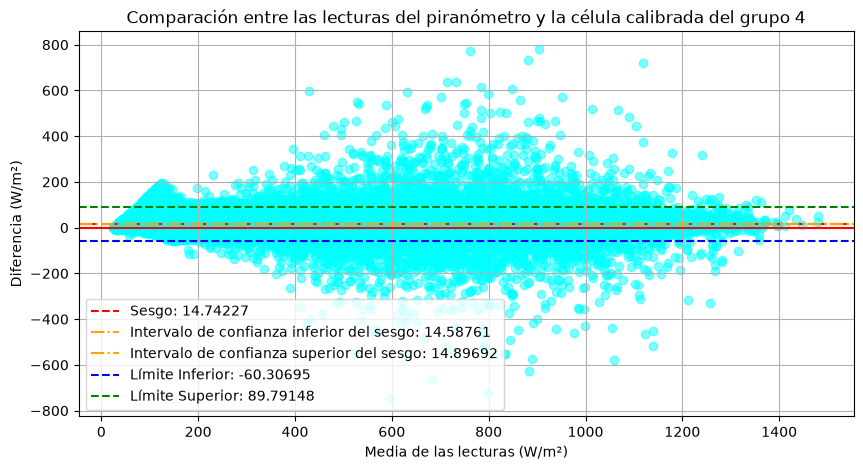

In [6]:
# Importo los datos desde el fichero CSV
df = dataframe()

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

resultado = bland_altman(df['PIR F1'], df['G FRONT'], df)

# Interpreto el resultado del análisis de Bland-Altman
interpretar_bland_altman(resultado, "W/m²")

# Muestro el gráfico de Bland-Altman
mostrar_bland_altman(resultado, 
                     "Comparación entre las lecturas del piranómetro y la célula calibrada del grupo 4", 
                     "W/m²")

### Tras comprobar que las mediciones no son sustituibles

Dado que las mediciones no son directamente sustituibles pero sí están fuertemente correlacionadas, podemos intentar encontrar una relación entre ambas variables.

#### Modelo de regresión lineal

En primer lugar, por simplicidad, se intentará hacer una regresión lineal entre ambas variables.

Resultados de la regresión lineal entre las lecturas del piranómetro y la célula calibrada del grupo 4:
- Pendiente: 0.99892
- Ordenada en el origen: -14.17930
- Coeficiente de correlación de Pearson: 0.99330
- Valor p de la regresión lineal: 0.00000
- Error estándar de la pendiente: 0.00024
- La correlación es estadísticamente significativa.

Resultados de Bland-Altman entre las predicciones de la regresión lineal y las lecturas reales del piranómetro:
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 29.46854 W/m², lo que indica que en promedio, una serie tiende a ser 29.46854 W/m² mayor que la otra.
- Los límites de acuerdo son [-45.50909, 104.44617] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.15451 W/m², lo que indica la precisión con la que se

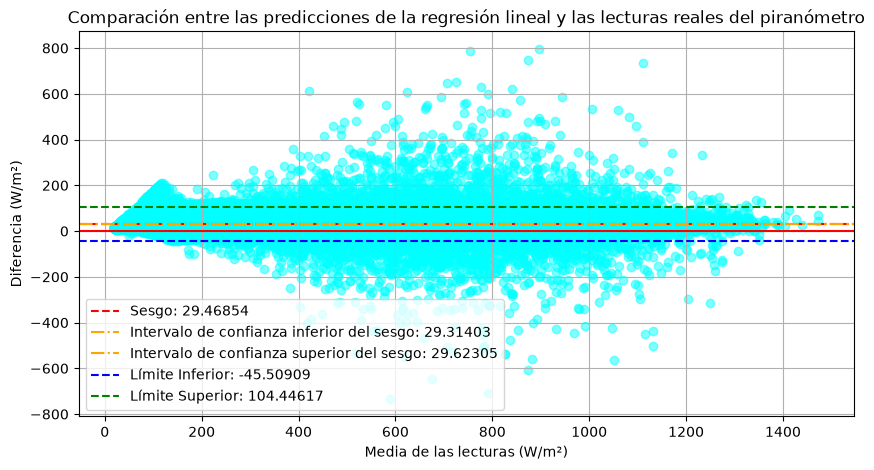

In [3]:
# Importo los datos desde el fichero CSV
df = dataframe()

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

# Calculo la regresión lineal para obtener el valor p y determinar si existe relación lineal entre las dos variables
resultado = linregress(df['PIR F1'], df['G FRONT'])

# Saco la pendiente, la ordenada en el origen, el coeficiente de correlación de Pearson y el valor p
pendiente, ordenada, pearson, p_valor, error_estandar = resultado

print(f"Resultados de la regresión lineal entre las lecturas del piranómetro y la célula calibrada del grupo 4:")
print(f"- Pendiente: {pendiente:.5f}")
print(f"- Ordenada en el origen: {ordenada:.5f}")
print(f"- Coeficiente de correlación de Pearson: {pearson:.5f}")
print(f"- Valor p de la regresión lineal: {p_valor:.5f}")
print(f"- Error estándar de la pendiente: {error_estandar:.5f}")
if p_valor < 0.05:
    print("- La correlación es estadísticamente significativa.")

# Si es estadísticamente significativa, compruebo que la predicción hecha por la regresión lineal se ajusta a los datos reales del piranómemtro con un Bland Altman entre las predicciones de la regresión lineal y las lecturas reales del piranómetro. Para ello, calculo las predicciones de la regresión lineal para cada lectura del piranómetro y luego hago un gráfico de Bland-Altman entre estas predicciones y las lecturas reales del piranómetro.
prediccion = pendiente * df['G FRONT'] + ordenada
print(f"\nResultados de Bland-Altman entre las predicciones de la regresión lineal y las lecturas reales del piranómetro:")
resultado = bland_altman(df['PIR F1'], prediccion,  df)

interpretar_bland_altman(resultado, "W/m²")

mostrar_bland_altman(resultado, 
                     "Comparación entre las predicciones de la regresión lineal y las lecturas reales del piranómetro", 
                     "W/m²")

#### Árbol CART

Dado que la correlación entre variables es fuerte pero no lineal, se intentará encontrar una relación entre ambas empleando un árbol de decisión CART.

In [8]:
# Cargamos el dataframe
df = dataframe()

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

df_entrenamiento, df_test = crear_conjuntos_aprendizaje_test(df, semilla=SEMILLA, prop_test=0.3)

Árbol obtenido:


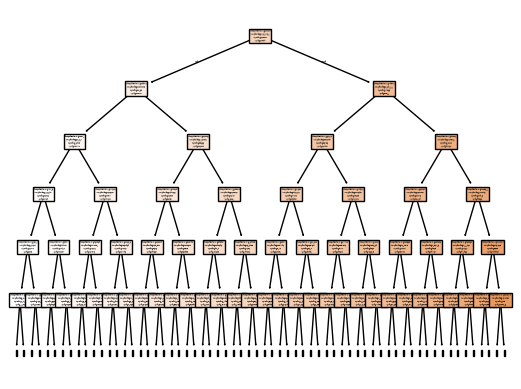


Resultados de Bland-Altman entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro:
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.02179 W/m², lo que indica que en promedio, una serie tiende a ser 0.02179 W/m² menor que la otra.
- Los límites de acuerdo son [-80.19647, 80.15289] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.30164 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


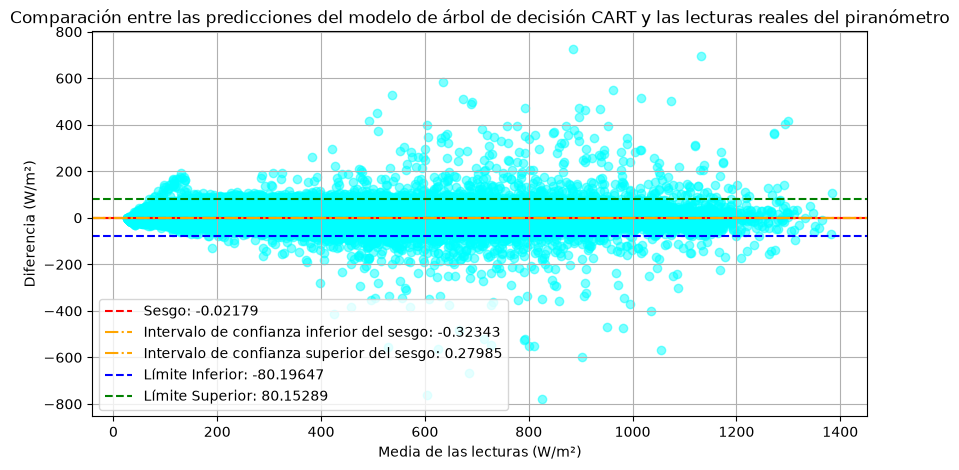

In [11]:
modelo = tree.DecisionTreeRegressor()
predictor = modelo.fit(df_entrenamiento['G FRONT'].values.reshape(-1, 1), df_entrenamiento['PIR F1'].values)

# Hago las predicciones del modelo de árbol de decisión CART para cada lectura de la célula calibrada
df_test["Pred_CART"] = predictor.predict(df_test['G FRONT'].values.reshape(-1, 1))

print(f"Árbol obtenido:")
tree.plot_tree(predictor, feature_names=['Lectura de G FRONT'], filled=True, max_depth=5)
plt.savefig(f"{DIR_SALIDA}/arbol_decision_pirf1_gfront.pdf", dpi=1200)
plt.show()

# Hago un Bland-Altman entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro
print(f"\nResultados de Bland-Altman entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro:")
resultado = bland_altman(df_test['PIR F1'], df_test['Pred_CART'],  df_test)

interpretar_bland_altman(resultado, "W/m²")

mostrar_bland_altman(resultado, 
                     "Comparación entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro", 
                     "W/m²")

## Predicción de piranómetros de grupo a partir de piranómetros horizontales

Dado que los piranómetros son dispositivos bastante caros, es interesante comprobar si es posible precedir las mediciones de irradiancia en un grupo de placas a partir de las mediciones de un piranómetro horizontal y un módulo sensor. Esto nos permitiría abaratar costes en instalaciones fotovoltaicas con más de un grupo de placas sin perder precisión en la medición de la irradiancia.

### Estudio de correleación entre piranómetros

El primer paso será estudiar la correlación entre las lecturas de los piranómetros. Esto nos permitirá saber si las mediciones tienen relación estadística y la \textit{fuerza} de esta.

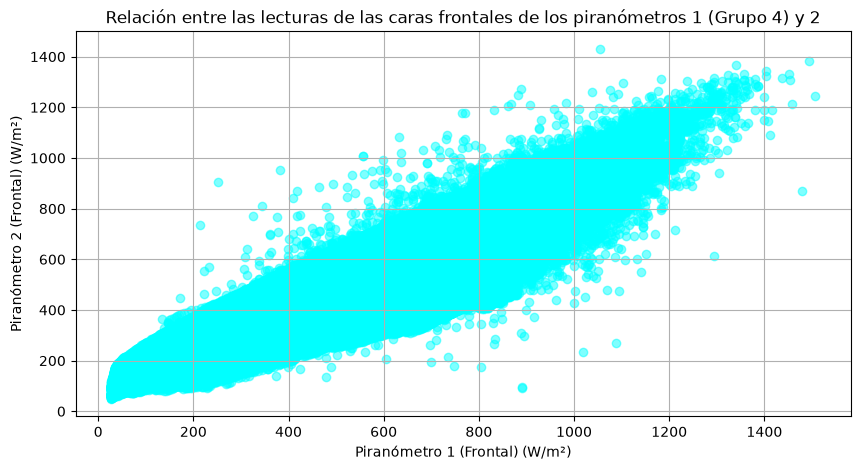

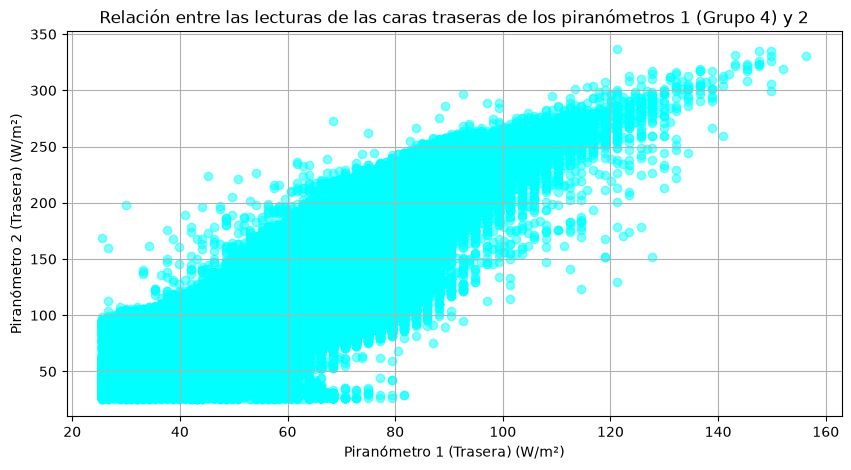

Resultados del análisis de regresión lineal entre las lecturas de los piranómetros 1 y 2:
- Valor p de la regresión lineal para las caras frontales: 0.00000 -> Correlación estadísticamente significativa
- Valor p de la regresión lineal para las caras traseras: 0.00000 -> Correlación estadísticamente significativa


In [9]:
df = dataframe()

# Elimino las filas con valores nulos en los piranómetros de grupo y horizontal; y el módulo sensor (grupo 4)
df = df.dropna(subset=['PIR F1', 'PIR R1', 'PIR F2', 'PIR R2', 'MOD SENSOR G4'], how='any')

# Visualizo la lectura del piranómetro de grupo y la del piranómetro horizontal enfrentadas
mostrar_scatter_plot(df['PIR F1'], 
                     df['PIR F2'],
                     'Relación entre las lecturas de las caras frontales de los piranómetros 1 (Grupo 4) y 2',
                     'Piranómetro 1 (Frontal)',
                     'Piranómetro 2 (Frontal)',
                     'W/m²',
                     'W/m²')
mostrar_scatter_plot(df['PIR R1'], 
                     df['PIR R2'],
                     'Relación entre las lecturas de las caras traseras de los piranómetros 1 (Grupo 4) y 2',
                     'Piranómetro 1 (Trasera)',
                     'Piranómetro 2 (Trasera)',
                     'W/m²',
                     'W/m²')

# Para estudiar la correlación, hago un análisis de regresión lineal
p_valor_frontal = linregress(df['PIR F1'], df['PIR F2'])[3]
p_valor_trasera = linregress(df['PIR R1'], df['PIR R2'])[3]

print("Resultados del análisis de regresión lineal entre las lecturas de los piranómetros 1 y 2:")
print(f"- Valor p de la regresión lineal para las caras frontales: {p_valor_frontal:.5f} -> {'Correlación estadísticamente significativa' if p_valor_frontal < 0.05 else 'Correlación no estadísticamente significativa'}")
print(f"- Valor p de la regresión lineal para las caras traseras: {p_valor_trasera:.5f} -> {'Correlación estadísticamente significativa' if p_valor_trasera < 0.05 else 'Correlación no estadísticamente significativa'}")

### Intento de predicción

#### Regresión lineal múltiple
En primer lugar, por simplicidad, se intentará hacer una regresión lineal múltiple entre las variables.

Resultados de la regresión lineal múltiple para las caras frontales:
- PIR_F1 = 5.93026 + 0.05429 * PIR_F2 + 17.20531 * MOD_SENSOR
Resultados de la regresión lineal múltiple para las caras traseras:
- PIR_R1 = 24.10615 + 0.36556 * PIR_R2 + -0.36847 * MOD_SENSOR
Resultados de Bland-Altman entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras frontales:
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.04093 W/m², lo que indica que en promedio, una serie tiende a ser 0.04093 W/m² menor que la otra.
- Los límites de acuerdo son [-70.93660, 70.85474] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.29833 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) 

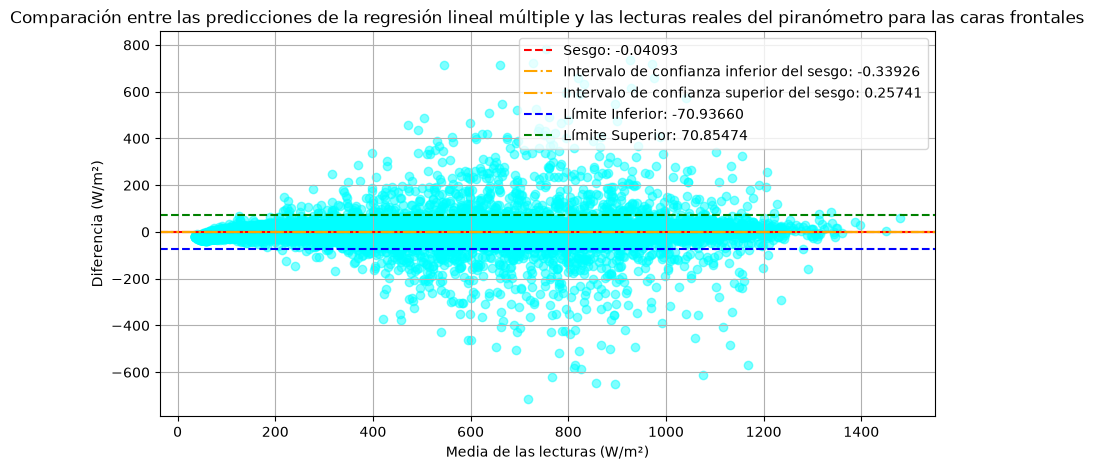

Resultados de Bland-Altman entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras traseras:
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 0.00909 W/m², lo que indica que en promedio, una serie tiende a ser 0.00909 W/m² mayor que la otra.
- Los límites de acuerdo son [-15.90215, 15.92033] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.06696 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


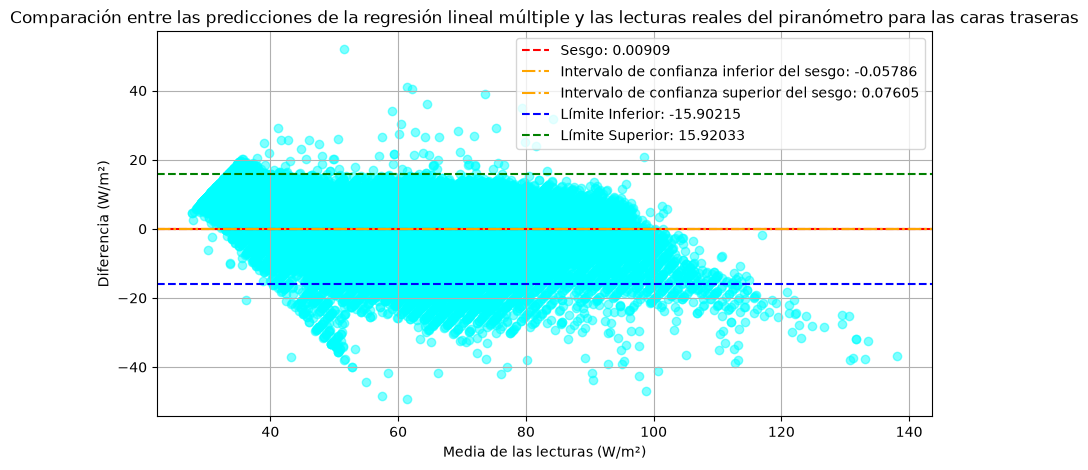

RMSE entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras frontales: 35.44753 W/m²
RMSE entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras traseras: 7.95555 W/m²


In [3]:
df = dataframe()

# Elimino las filas con valores nulos en los piranómetros de grupo y horizontal; y el módulo sensor (grupo 4)
df = df.dropna(subset=['PIR F1', 'PIR R1', 'PIR F2', 'PIR R2', 'MOD SENSOR G4'], how='any')

df_entrenamiento, df_test = crear_conjuntos_aprendizaje_test(df, semilla=SEMILLA, prop_test=0.3)

# Creo el modelo de regresión lineal múltiple para las caras frontales y traseras
X_F = df_entrenamiento[['PIR F2', 'MOD SENSOR G4']]
y_F = df_entrenamiento['PIR F1']

X_F_test = df_test[['PIR F2', 'MOD SENSOR G4']]
y_F_test = df_test['PIR F1']

modelo_F = LinearRegression()
modelo_F.fit(X_F, y_F)

X_R = df_entrenamiento[['PIR R2', 'MOD SENSOR G4']]
y_R = df_entrenamiento['PIR R1']

X_R_test = df_test[['PIR R2', 'MOD SENSOR G4']]
y_R_test = df_test['PIR R1']

modelo_R = LinearRegression()
modelo_R.fit(X_R, y_R)

# Obtenemos los coeficientes y pvalores de la regresión lineal múltiple para las caras frontales y traseras
coeficientes_F = modelo_F.coef_
intercept_F = modelo_F.intercept_
coeficientes_R = modelo_R.coef_
intercept_R = modelo_R.intercept_
print("Resultados de la regresión lineal múltiple para las caras frontales:")
print(f"- PIR_F1 = {intercept_F:.5f} + {coeficientes_F[0]:.5f} * PIR_F2 + {coeficientes_F[1]:.5f} * MOD_SENSOR")
print("Resultados de la regresión lineal múltiple para las caras traseras:")
print(f"- PIR_R1 = {intercept_R:.5f} + {coeficientes_R[0]:.5f} * PIR_R2 + {coeficientes_R[1]:.5f} * MOD_SENSOR")

# Comprobamos el ajuste de la regresión lineal múltiple con un Bland-Altman entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras frontales y traseras
df_test['prediccion_F'] = modelo_F.predict(X_F_test)
df_test['prediccion_R'] = modelo_R.predict(X_R_test)

resultados_F = bland_altman(df_test['PIR F1'], df_test['prediccion_F'],  df_test)
resultados_R = bland_altman(df_test['prediccion_R'], df_test['PIR R1'], df_test)

print(f"Resultados de Bland-Altman entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras frontales:")
interpretar_bland_altman(resultados_F, "W/m²")
mostrar_bland_altman(resultados_F, 
                     "Comparación entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras frontales", 
                     "W/m²")

print(f"Resultados de Bland-Altman entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras traseras:")
interpretar_bland_altman(resultados_R, "W/m²")
mostrar_bland_altman(resultados_R, 
                     "Comparación entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras traseras", 
                     "W/m²")

# Calculo RMSE entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras frontales y traseras
rmse_F = rmse(df_test['PIR F1'], df_test['prediccion_F'])
rmse_R = rmse(df_test['PIR R1'], df_test['prediccion_R'])
print(f"RMSE entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras frontales: {rmse_F:.5f} W/m²")
print(f"RMSE entre las predicciones de la regresión lineal múltiple y las lecturas reales del piranómetro para las caras traseras: {rmse_R:.5f} W/m²")

fila_reg_lin_mult_F = fila_diferencia_series("R. lineal múlt. (Frontal)", df_test['PIR F1'], df_test['prediccion_F']) # Compongo la fila para crear la tabla de diferencias posteriormente
fila_reg_lin_mult_R = fila_diferencia_series("R. lineal múlt. (Trasera)", df_test['PIR R1'], df_test['prediccion_R']) # Compongo la fila para crear la tabla de diferencias posteriormente

In [4]:
print(tabla_diferencias([fila_reg_lin_mult_F, fila_reg_lin_mult_R]))

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
R. lineal múlt. (Frontal) & 35.447531 & 17.242414 & 4.704369 \\
R. lineal múlt. (Trasera) & 7.955552 & 6.226204 & 11.575500 \\
\bottomrule
\end{tabular}



#### Árboles de decisión CART

Pese a que hemos podido predecir las mediciones correctamente, es posible que haya modelos mejores que nos permitan reducir el error. Probaremos con un árbol de decisión CART para intentar mejorar la predicción.

Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 0.16283 W/m², lo que indica que en promedio, una serie tiende a ser 0.16283 W/m² mayor que la otra.
- Los límites de acuerdo son [-88.36728, 88.69294] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.37254 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


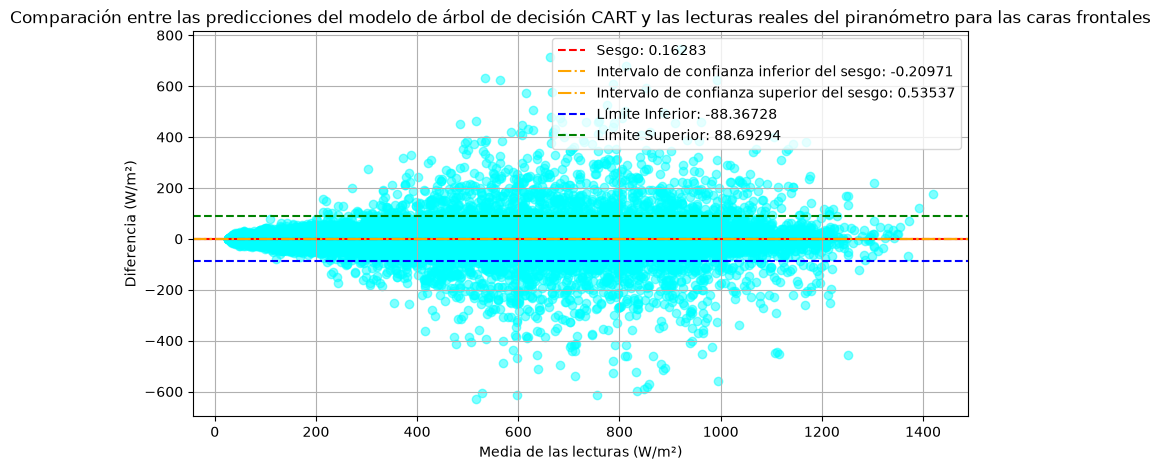

Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.02189 W/m², lo que indica que en promedio, una serie tiende a ser 0.02189 W/m² menor que la otra.
- Los límites de acuerdo son [-15.32962, 15.28583] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.06442 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


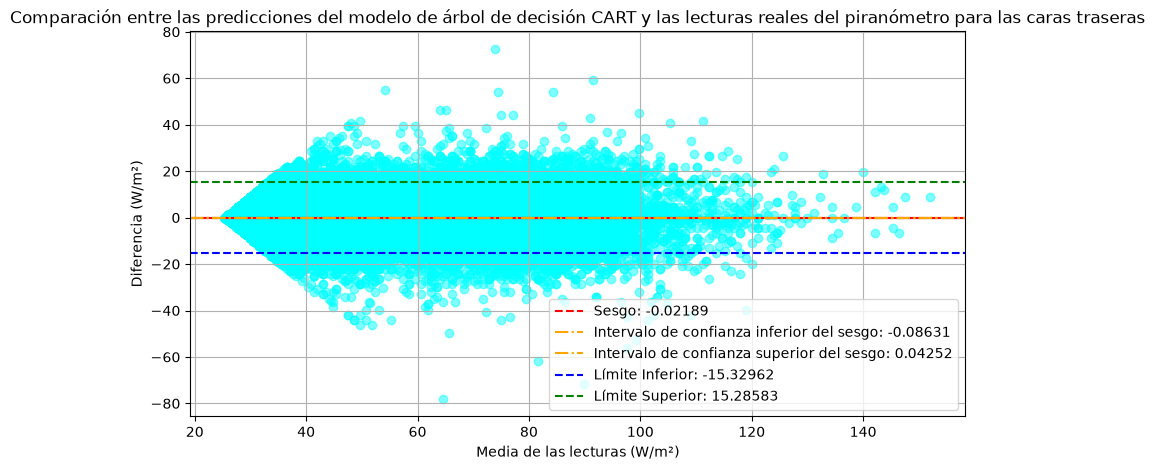

RMSE entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro para las caras frontales: 44.26495 W/m²
RMSE entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro para las caras traseras: 7.65382 W/m²


In [5]:
df = dataframe()

# Elimino las filas con valores nulos en los piranómetros de grupo y horizontal; y el módulo sensor (grupo 4)
df = df.dropna(subset=['PIR F1', 'PIR R1', 'PIR F2', 'PIR R2', 'MOD SENSOR G4'], how='any')

df_entrenamiento, df_test = crear_conjuntos_aprendizaje_test(df, semilla=SEMILLA, prop_test=0.3)

# Creo los árboles de decisión para las caras frontales y traseras
X_F = df_entrenamiento[['PIR F2', 'MOD SENSOR G4']]
y_F = df_entrenamiento['PIR F1']

X_F_test = df_test[['PIR F2', 'MOD SENSOR G4']]
y_F_test = df_test['PIR F1']

modelo_F = tree.DecisionTreeRegressor()
modelo_F.fit(X_F, y_F)

X_R = df_entrenamiento[['PIR R2', 'MOD SENSOR G4']]
y_R = df_entrenamiento['PIR R1']

X_R_test = df_test[['PIR R2', 'MOD SENSOR G4']]
y_R_test = df_test['PIR R1']

modelo_R = tree.DecisionTreeRegressor()
modelo_R.fit(X_R, y_R)

# Obtenemos las predicciones del modelo de árbol de decisión CART para las caras frontales y traseras
df_test['prediccion_cart_F'] = modelo_F.predict(X_F_test)
df_test['prediccion_cart_R'] = modelo_R.predict(X_R_test)

# Hacemos el Bland-Altman
resultados_F = bland_altman(df_test['PIR F1'], df_test['prediccion_cart_F'], df_test)
resultados_R = bland_altman(df_test['PIR R1'], df_test['prediccion_cart_R'], df_test)

interpretar_bland_altman(resultados_F, "W/m²")
mostrar_bland_altman(resultados_F, 
                     "Comparación entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro para las caras frontales", 
                     "W/m²")

interpretar_bland_altman(resultados_R, "W/m²")
mostrar_bland_altman(resultados_R, 
                     "Comparación entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro para las caras traseras", 
                     "W/m²")

# Calculo RMSE entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro para las caras frontales y traseras
rmse_cart_F = rmse(df_test['PIR F1'], df_test['prediccion_cart_F'])
rmse_cart_R = rmse(df_test['PIR R1'], df_test['prediccion_cart_R'])
print(f"RMSE entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro para las caras frontales: {rmse_cart_F:.5f} W/m²")
print(f"RMSE entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro para las caras traseras: {rmse_cart_R:.5f} W/m²")

# Compongo las filas para crear la tabla de diferencias posteriormente
fila_cart_F = fila_diferencia_series("Árbol de decisión CART (Frontal)", df_test['prediccion_cart_F'], df_test['PIR F1'])
fila_cart_R = fila_diferencia_series("Árbol de decisión CART (Trasera)", df_test['prediccion_cart_R'], df_test['PIR R1'])

In [6]:
print(tabla_diferencias([fila_cart_F, fila_cart_R]))

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
Árbol de decisión CART (Frontal) & 44.264946 & 20.695006 & 4.493085 \\
Árbol de decisión CART (Trasera) & 7.653823 & 5.474518 & 9.728100 \\
\bottomrule
\end{tabular}



#### Bosques aleatorios (Random Forest)

Dado que el árbol de decisión CART es un modelo bastante simple, es posible que un modelo más complejo como un bosque aleatorio (Random Forest) nos permita mejorar la predicción. Probaremos con este modelo para intentar mejorar la precisión.

##### 10 árboles

Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.03836 W/m², lo que indica que en promedio, una serie tiende a ser 0.03836 W/m² menor que la otra.
- Los límites de acuerdo son [-70.89018, 70.81345] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.29815 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


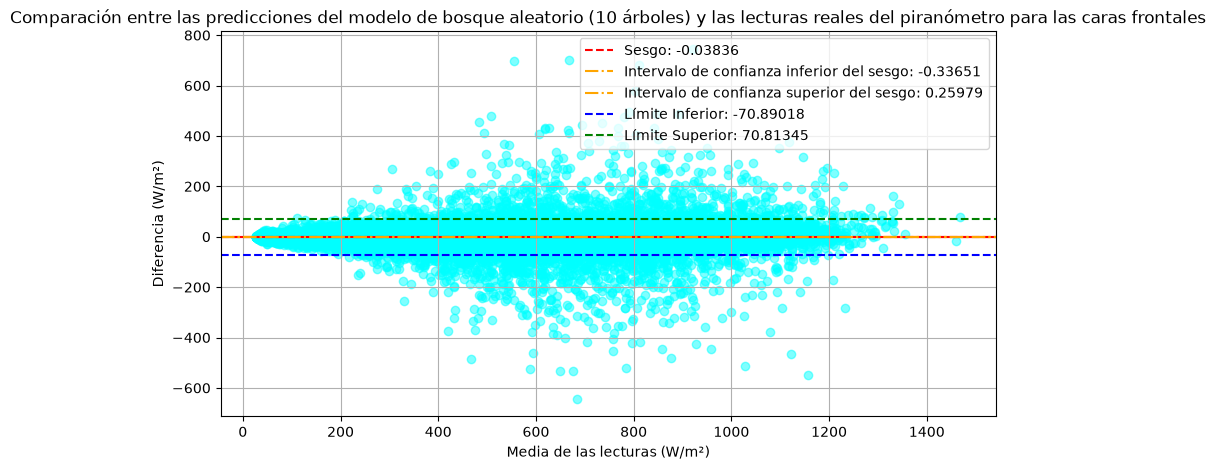

Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.01274 W/m², lo que indica que en promedio, una serie tiende a ser 0.01274 W/m² menor que la otra.
- Los límites de acuerdo son [-12.93667, 12.91119] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.05438 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


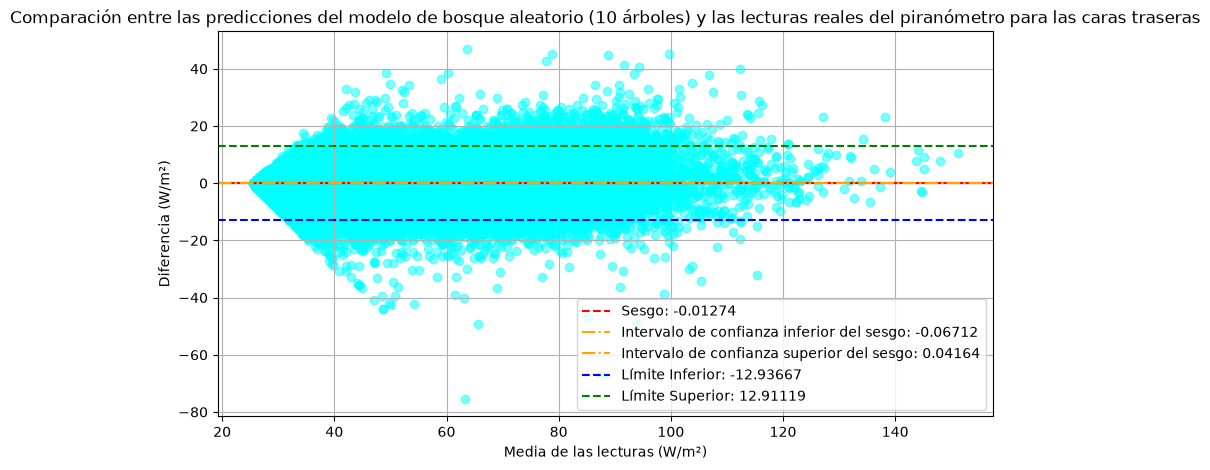

RMSE entre las predicciones del modelo de bosque aleatorio (10 árboles) y las lecturas reales del piranómetro para las caras frontales: 35.42560 W/m²
RMSE entre las predicciones del modelo de bosque aleatorio (10 árboles) y las lecturas reales del piranómetro para las caras traseras: 6.46192 W/m²


In [8]:
df = dataframe()

# Elimino las filas con valores nulos en los piranómetros de grupo y horizontal; y el módulo sensor (grupo 4)
df = df.dropna(subset=['PIR F1', 'PIR R1', 'PIR F2', 'PIR R2', 'MOD SENSOR G4'], how='any')

df_entrenamiento, df_test = crear_conjuntos_aprendizaje_test(df, semilla=SEMILLA, prop_test=0.3)

# Creo el modelo de bosque aleatorio para las caras frontales y traseras
X_F = df_entrenamiento[['PIR F2', 'MOD SENSOR G4']]
y_F = df_entrenamiento['PIR F1']

X_F_test = df_test[['PIR F2', 'MOD SENSOR G4']]
y_F_test = df_test['PIR F1']

modelo_F = RandomForestRegressor(n_estimators=10, random_state=SEMILLA, n_jobs=-1)
modelo_F.fit(X_F, y_F)

X_R = df_entrenamiento[['PIR R2', 'MOD SENSOR G4']]
y_R = df_entrenamiento['PIR R1']

X_R_test = df_test[['PIR R2', 'MOD SENSOR G4']]
y_R_test = df_test['PIR R1']

modelo_R = RandomForestRegressor(n_estimators=10, random_state=SEMILLA, n_jobs=-1)
modelo_R.fit(X_R, y_R)

# Obtenemos las predicciones del modelo de bosque aleatorio para las caras frontales y traseras
df_test['prediccion_rf_F'] = modelo_F.predict(X_F_test)
df_test['prediccion_rf_R'] = modelo_R.predict(X_R_test)

# Hacemos el Bland-Altman
resultados_F = bland_altman(df_test['PIR F1'], df_test['prediccion_rf_F'], df_test)
resultados_R = bland_altman(df_test['PIR R1'], df_test['prediccion_rf_R'], df_test)

interpretar_bland_altman(resultados_F, "W/m²")
mostrar_bland_altman(resultados_F, 
                     "Comparación entre las predicciones del modelo de bosque aleatorio (10 árboles) y las lecturas reales del piranómetro para las caras frontales", 
                     "W/m²")

interpretar_bland_altman(resultados_R, "W/m²")
mostrar_bland_altman(resultados_R, 
                     "Comparación entre las predicciones del modelo de bosque aleatorio (10 árboles) y las lecturas reales del piranómetro para las caras traseras", 
                     "W/m²")

# Calculo RMSE entre las predicciones del modelo de bosque aleatorio y las lecturas reales del piranómetro para las caras frontales y traseras
rmse_rf_F = rmse(df_test['PIR F1'], df_test['prediccion_rf_F'])
rmse_rf_R = rmse(df_test['PIR R1'], df_test['prediccion_rf_R'])
print(f"RMSE entre las predicciones del modelo de bosque aleatorio (10 árboles) y las lecturas reales del piranómetro para las caras frontales: {rmse_rf_F:.5f} W/m²")
print(f"RMSE entre las predicciones del modelo de bosque aleatorio (10 árboles) y las lecturas reales del piranómetro para las caras traseras: {rmse_rf_R:.5f} W/m²")

# Compongo las filas para crear la tabla de diferencias posteriormente
fila_rf_F_10 = fila_diferencia_series("r. forest (10 árboles)(Frontal)", df_test['prediccion_rf_F'], df_test['PIR F1'])
fila_rf_R_10 = fila_diferencia_series("r. forest (10 árboles)(Trasera)", df_test['prediccion_rf_R'], df_test['PIR R1'])

In [9]:
print(tabla_diferencias([fila_rf_F_10, fila_rf_R_10]))

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
r. forest (10 árboles)(Frontal) & 35.425601 & 17.141289 & 3.705710 \\
r. forest (10 árboles)(Trasera) & 6.461916 & 4.714883 & 8.283209 \\
\bottomrule
\end{tabular}



##### 100 árboles

Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 0.02951 W/m², lo que indica que en promedio, una serie tiende a ser 0.02951 W/m² mayor que la otra.
- Los límites de acuerdo son [-68.81130, 68.87032] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.28969 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


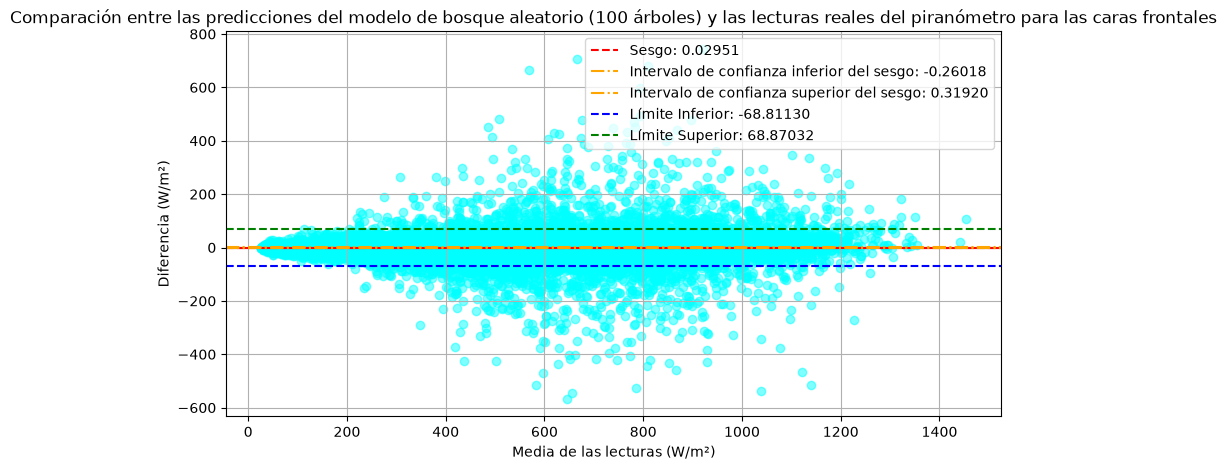

Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.00798 W/m², lo que indica que en promedio, una serie tiende a ser 0.00798 W/m² menor que la otra.
- Los límites de acuerdo son [-12.66047, 12.64451] W/m², lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.05324 W/m², lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


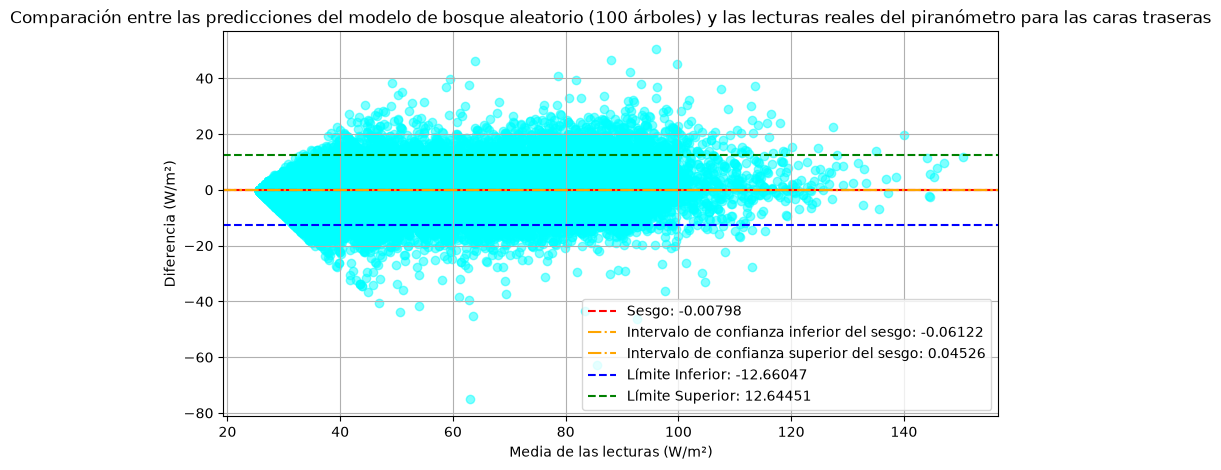

RMSE entre las predicciones del modelo de bosque aleatorio (100 árboles) y las lecturas reales del piranómetro para las caras frontales: 34.42010 W/m²
RMSE entre las predicciones del modelo de bosque aleatorio (100 árboles) y las lecturas reales del piranómetro para las caras traseras: 6.32619 W/m²


In [10]:
df = dataframe()

# Elimino las filas con valores nulos en los piranómetros de grupo y horizontal; y el módulo sensor (grupo 4)
df = df.dropna(subset=['PIR F1', 'PIR R1', 'PIR F2', 'PIR R2', 'MOD SENSOR G4'], how='any')

df_entrenamiento, df_test = crear_conjuntos_aprendizaje_test(df, semilla=SEMILLA, prop_test=0.3)

# Creo el modelo de bosque aleatorio para las caras frontales y traseras
X_F = df_entrenamiento[['PIR F2', 'MOD SENSOR G4']]
y_F = df_entrenamiento['PIR F1']

X_F_test = df_test[['PIR F2', 'MOD SENSOR G4']]
y_F_test = df_test['PIR F1']

modelo_F = RandomForestRegressor(n_estimators=100, random_state=SEMILLA, n_jobs=-1)
modelo_F.fit(X_F, y_F)

X_R = df_entrenamiento[['PIR R2', 'MOD SENSOR G4']]
y_R = df_entrenamiento['PIR R1']

X_R_test = df_test[['PIR R2', 'MOD SENSOR G4']]
y_R_test = df_test['PIR R1']

modelo_R = RandomForestRegressor(n_estimators=100, random_state=SEMILLA, n_jobs=-1)
modelo_R.fit(X_R, y_R)

# Obtenemos las predicciones del modelo de bosque aleatorio para las caras frontales y traseras
df_test['prediccion_rf_F'] = modelo_F.predict(X_F_test)
df_test['prediccion_rf_R'] = modelo_R.predict(X_R_test)

# Hacemos el Bland-Altman
resultados_F = bland_altman(df_test['PIR F1'], df_test['prediccion_rf_F'], df_test)
resultados_R = bland_altman(df_test['PIR R1'], df_test['prediccion_rf_R'], df_test)

interpretar_bland_altman(resultados_F, "W/m²")
mostrar_bland_altman(resultados_F, 
                     "Comparación entre las predicciones del modelo de bosque aleatorio (100 árboles) y las lecturas reales del piranómetro para las caras frontales", 
                     "W/m²")

interpretar_bland_altman(resultados_R, "W/m²")
mostrar_bland_altman(resultados_R, 
                     "Comparación entre las predicciones del modelo de bosque aleatorio (100 árboles) y las lecturas reales del piranómetro para las caras traseras", 
                     "W/m²")

# Calculo RMSE entre las predicciones del modelo de bosque aleatorio y las lecturas reales del piranómetro para las caras frontales y traseras
rmse_rf_F = rmse(df_test['prediccion_rf_F'], df_test['PIR F1'])
rmse_rf_R = rmse(df_test['prediccion_rf_R'], df_test['PIR R1'])
print(f"RMSE entre las predicciones del modelo de bosque aleatorio (100 árboles) y las lecturas reales del piranómetro para las caras frontales: {rmse_rf_F:.5f} W/m²")
print(f"RMSE entre las predicciones del modelo de bosque aleatorio (100 árboles) y las lecturas reales del piranómetro para las caras traseras: {rmse_rf_R:.5f} W/m²")

# Compongo las filas para crear la tabla de diferencias posteriormente
fila_rf_F_100 = fila_diferencia_series("r. forest (100 árboles)(Frontal)", df_test['prediccion_rf_F'], df_test['PIR F1'])
fila_rf_R_100 = fila_diferencia_series("r. forest (100 árboles)(Trasera)", df_test['prediccion_rf_R'], df_test['PIR R1'])

In [11]:
print(tabla_diferencias([fila_rf_F_100, fila_rf_R_100]))

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
r. forest (100 árboles)(Frontal) & 34.420099 & 16.551802 & 3.584956 \\
r. forest (100 árboles)(Trasera) & 6.326191 & 4.628164 & 8.131942 \\
\bottomrule
\end{tabular}



In [12]:
print(tabla_diferencias([fila_rf_F_10, fila_rf_F_100, fila_rf_R_10, fila_rf_R_100]))

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
r. forest (10 árboles)(Frontal) & 35.425601 & 17.141289 & 3.705710 \\
r. forest (100 árboles)(Frontal) & 34.420099 & 16.551802 & 3.584956 \\
r. forest (10 árboles)(Trasera) & 6.461916 & 4.714883 & 8.283209 \\
r. forest (100 árboles)(Trasera) & 6.326191 & 4.628164 & 8.131942 \\
\bottomrule
\end{tabular}



### Conclusiones

In [13]:
print(tabla_diferencias([fila_reg_lin_mult_F,
                         fila_cart_F,
                         fila_rf_F_10,
                         fila_rf_F_100]))
print(tabla_diferencias([fila_reg_lin_mult_R,
                         fila_cart_R,
                         fila_rf_R_10,
                         fila_rf_R_100]))

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
R. lineal múlt. (Frontal) & 35.447531 & 17.242414 & 4.704369 \\
Árbol de decisión CART (Frontal) & 44.264946 & 20.695006 & 4.493085 \\
r. forest (10 árboles)(Frontal) & 35.425601 & 17.141289 & 3.705710 \\
r. forest (100 árboles)(Frontal) & 34.420099 & 16.551802 & 3.584956 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} \\
\midrule
R. lineal múlt. (Trasera) & 7.955552 & 6.226204 & 11.575500 \\
Árbol de decisión CART (Trasera) & 7.653823 & 5.474518 & 9.728100 \\
r. forest (10 árboles)(Trasera) & 6.461916 & 4.714883 & 8.283209 \\
r. forest (100 árboles)(Trasera) & 6.326191 & 4.628164 & 8.131942 \\
\bottomrule
\end{tabular}

